# 03 — The Fleishman generator

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/03_fleishman_generator.ipynb)

Section 3 of the paper: Fleishman's cubic transformation per asset, the
Vale-Maurelli equation per pair for the correlation of the underlying normals,
then a Gaussian vector transformed asset by asset. Every output is inspected.

Runtime: seconds.

## Import and targets

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import Targets, FleishmanMarket

cvinemarketgen 0.2.0


## Import and targets

Four assets with the table's means $\mu_i$, volatilities $\sigma_i$ and
correlations $\Sigma^*_{ik}$, plus a skewness $\gamma_{1,i}$ and a raw
kurtosis $\gamma_{2,i}$ given by hand (annual, in decimals for the first two
moments). The generator works with the excess kurtosis $\gamma_{2,i} - 3$
internally; the summary prints the raw value.

In [2]:
assets = ["U.S. Large Cap", "U.S. Long Treasuries", "Commodities", "Gold"]
table = pd.read_csv(os.path.join(ROOT, "data", "jpm_ltcma_2024.csv"), index_col="Assets")
t = Targets.from_ltcma(table, assets=assets,
                       skew={"U.S. Large Cap": -0.56, "U.S. Long Treasuries": 0.07, "Commodities": -0.51, "Gold": 0.21},
                       kurt={"U.S. Large Cap": 3.79, "U.S. Long Treasuries": 4.06, "Commodities": 4.69, "Gold": 3.64})
t.summary();

Targets for 4 assets (returns layer)
                        mean     vol  skew  kurt
U.S. Large Cap        0.0819  0.1619 -0.56  3.79
U.S. Long Treasuries  0.0592  0.1239  0.07  4.06
Commodities           0.0531  0.1800 -0.51  4.69
Gold                  0.0543  0.1693  0.21  3.64

correlation matrix:
                      U.S. Large Cap  U.S. Long Treasuries  Commodities  Gold
Assets                                                                       
U.S. Large Cap                  1.00                 -0.10         0.45  0.03
U.S. Long Treasuries           -0.10                  1.00        -0.23  0.31
Commodities                     0.45                 -0.23         1.00  0.36
Gold                            0.03                  0.31         0.36  1.00

skewness and kurtosis: given


## Fit

Steps 1 and 2 of Section 3.2 of the paper. Step 1, per asset: the coefficients
$(a_i, b_i, c_i, d_i)$ of the cubic $Y_i = a_i + b_i Z_i + c_i Z_i^2 + d_i Z_i^3$,
$Z_i \sim N(0, 1)$, such that $Y_i$ has mean 0, variance 1, skewness
$\gamma_{1,i}$ and kurtosis $\gamma_{2,i}$: with $a_i = -c_i$ for the mean, the
three remaining moment equations

$$
b^2 + 6bd + 2c^2 + 15d^2 = 1, \qquad 2c\,(b^2 + 24bd + 105d^2 + 2) = \gamma_1, \qquad 24\,[bd + c^2(1 + b^2 + 28bd) + d^2(12 + 48bd + 141c^2 + 225d^2)] = \gamma_2 - 3
$$

are solved by `fsolve`, started from a Nelder-Mead minimiser of the squared
mismatch. Step 2, per pair: the correlation $\rho^Z_{ik}$ of the two underlying
normals that gives the target correlation $\Sigma^*_{ik}$ of the transformed
variables, the real root in $[-1, 1]$ of the Vale-Maurelli cubic

$$
\Sigma^*_{ik} = \rho^Z_{ik}\,(b_i b_k + 3 b_i d_k + 3 d_i b_k + 9 d_i d_k) + (\rho^Z_{ik})^2\, 2 c_i c_k + (\rho^Z_{ik})^3\, 6 d_i d_k,
$$

closest to $\Sigma^*_{ik}$ when several exist. The matrix $\Sigma^Z$ of these
roots is projected on the nearest positive-definite matrix before it is
factorised.

In [3]:
fm = FleishmanMarket(t).fit()

### The Fleishman coefficients, one row per asset

$(a_i, b_i, c_i, d_i)$ with the residual of the moment equations and the
feasibility flag. Read them: $c_i$ has the sign of the skewness ($a_i = -c_i$),
$d_i > 0$ raises the kurtosis, and $b_i < 1$ compensates so that the variance
stays at one. A pair $(\gamma_1, \gamma_2)$ below the boundary
$\gamma_2 - 3 = \gamma_1^2 - 2$ has no real solution and would be flagged
infeasible.

In [4]:
fm.coefficients.round(4)

,a,b,c,d
U.S. Large Cap,0.0864,0.9500,-0.0864,0.0140
U.S. Long Treasuries,-0.0097,0.8987,0.0097,0.0327
Commodities,0.0679,0.8713,-0.0679,0.0398
Gold,-0.0311,0.9371,0.0311,0.0202


### The intermediate correlations

The Vale-Maurelli equation gives, for each pair, the correlation of the
underlying normals that produces the target correlation of the transformed
returns. The cell prints $\Sigma^Z - \Sigma^*$: the intermediate correlations
differ slightly from the targets, by an amount that grows with the departure
of the cubics from the identity ($|\rho^Z| > |\Sigma^*|$, since a non-linear
transform attenuates linear correlation). `infeasible_pairs` lists the pairs
for which the cubic has no real root in $[-1, 1]$, which happens for strong
correlations between very non-normal marginals; none here.

In [5]:
print("infeasible pairs:", fm.infeasible_pairs)
(fm.intermediate_corr - t.corr).round(4)

infeasible pairs: []


,U.S. Large Cap,U.S. Long Treasuries,Commodities,Gold
U.S. Large Cap,0.0000,-0.0011,0.0052,0.0004
U.S. Long Treasuries,-0.0011,0.0000,-0.0028,0.0015
Commodities,0.0052,-0.0028,0.0000,0.0045
Gold,0.0004,0.0015,0.0045,0.0000


## Simulate and inspect

Step 3 of Section 3.2 with the accept-reject loop of Algorithm 5. One draw:
$Z = \varepsilon L^\top$ with $\varepsilon$ an $n \times N$ matrix of i.i.d.
standard normals and $L$ the Cholesky factor of $\Sigma^Z$, so that the rows
of $Z$ are Gaussian with correlation $\Sigma^Z$; then per asset the
coefficients are re-fitted on the drawn column $Z_i$ so that the empirical
moments of the cubic match the targets exactly on this draw, and
$X_i = \mu_i + \sigma_i\,(a_i + b_i Z_i + c_i Z_i^2 + d_i Z_i^3)$. The draw is
accepted when the largest errors satisfy
$|\hat\mu_i - \mu_i|, |\hat\sigma_i - \sigma_i| \le 2 \times 10^{-4}$,
$|\hat\gamma_{1,i} - \gamma_{1,i}|, |\hat\gamma_{2,i} - \gamma_{2,i}| \le 5 \times 10^{-2}$
and $\max_{i \ne k} |\hat\Sigma_{ik} - \Sigma^*_{ik}| \le 0.02$; otherwise a
new $\varepsilon$ is drawn. The diagnostics compare the four target moments
with the sample moments of the accepted draw.

In [6]:
X = fm.simulate(25000, seed=1)
d = fm.diagnostics(X)
d.summary();

25000 simulated observations (returns layer)
                      mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
U.S. Large Cap             0.0819          0.0819        0.0      0.1619         0.1619       0.0        -0.56           -0.56       -0.0         3.79          3.7904     0.0004
U.S. Long Treasuries       0.0592          0.0592        0.0      0.1239         0.1239       0.0         0.07            0.07        0.0         4.06          4.0605     0.0005
Commodities                0.0531          0.0531       -0.0      0.1800         0.1800       0.0        -0.51           -0.51       -0.0         4.69          4.6906     0.0006
Gold                       0.0543          0.0543       -0.0      0.1693         0.1693       0.0         0.21            0.21        0.0         3.64          3.6404     0.0004

max |diff| per moment: mean 6.1e-16, vol 3.6e-06, skew 3.4e-05, 

The correlation error $\hat\Sigma - \Sigma^*$ in percentage points: every
off-diagonal entry is within the 2-point tolerance of the loop.

In [7]:
(d.corr_error * 100).round(2)       # percentage points

,U.S. Large Cap,U.S. Long Treasuries,Commodities,Gold
U.S. Large Cap,0.00,-1.40,-0.76,-0.06
U.S. Long Treasuries,-1.40,0.00,-1.31,-1.57
Commodities,-0.76,-1.31,0.00,-0.06
Gold,-0.06,-1.57,-0.06,0.00


## What this generator cannot do

Its dependence is that of a Gaussian vector: whatever the marginals, the copula
of $(X_1, \dots, X_N)$ is the Gaussian copula with correlation $\Sigma^Z$,
because each $X_i$ is a monotone function of $Z_i$ on the relevant range and a
copula is invariant to monotone transforms of the marginals. A Gaussian copula
has $\lambda_L = \lambda_U = 0$, so the exceedance-correlation curves
$\hat\rho(z)$ of Section 4.5.4 are smooth and symmetric, with no jump at zero
and no sign change. The plot draws them for the central asset against the
others, the horizontal dotted line at the target $\Sigma^*_{ik}$. Compare with
notebooks 04 to 07.

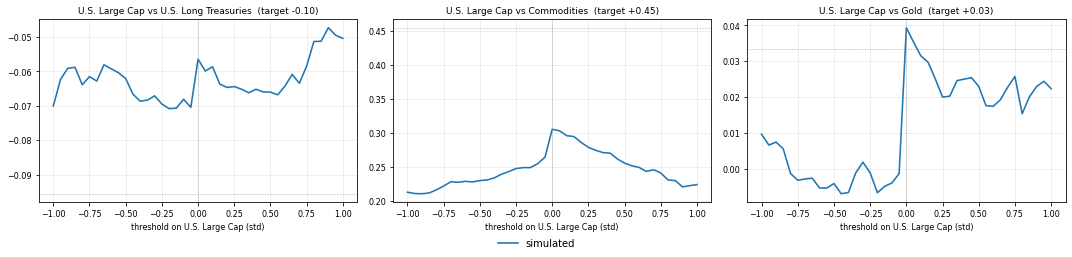

In [8]:
fm.plot_exceedance(X, base="U.S. Large Cap");

## Paths and save

`simulate_paths` reshapes one cross-section of $1000 \times 10$ i.i.d. period
returns into 1,000 paths of 10 periods; the terminal cumulative return
$\prod_{t=1}^{10}(1 + r_t) - 1$ is summarised by its 5, 50 and 95 percent
quantiles across paths.

In [9]:
P = fm.simulate_paths(n_paths=1000, horizon=10, seed=2)
print(P)
P.terminal().quantile([0.05, 0.5, 0.95]).round(3)

Paths(n_paths=1000, horizon=10, assets=4, returns)


,U.S. Large Cap,U.S. Long Treasuries,Commodities,Gold
0.05,-0.237,-0.108,-0.518,-0.372
0.50,1.019,0.678,0.529,0.509
0.95,3.315,1.937,2.427,2.583


`save` writes the targets and the fitted coefficients to JSON; `load` refits
the model from the targets (the fit is deterministic and takes a second), and
returns the same coefficient table.

In [10]:
fm.save("fleishman_market.json")
FleishmanMarket.load("fleishman_market.json").coefficients.round(4)

,a,b,c,d
U.S. Large Cap,0.0864,0.9500,-0.0864,0.0140
U.S. Long Treasuries,-0.0097,0.8987,0.0097,0.0327
Commodities,0.0679,0.8713,-0.0679,0.0398
Gold,-0.0311,0.9371,0.0311,0.0202
